In [ ]:
import torch
from torch import nn

#vision libraries
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor

#plotting
import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)

2.11.0+cpu
0.26.0+cpu


##Getting Dataset

In [ ]:
def getFashionMnistData():
    train_data = datasets.FashionMNIST(
      root="data",
      train=True,
      download=True,
      transform=ToTensor(),
      target_transform=None
    )

    test_data = datasets.FashionMNIST(
      root="data",
      train=False,
      download=True,
      transform=ToTensor(),
      target_transform=None
    )

    return train_data, test_data

In [ ]:
train_data, test_data = getFashionMnistData()

In [ ]:
print(train_data)

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()


In [ ]:
print(test_data)

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()


In [ ]:
image, label = train_data[0]

image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
print(image.shape)

torch.Size([1, 28, 28])


In [ ]:
print(label)

9


In [ ]:
print(train_data.classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [ ]:
class_names = train_data.classes

In [ ]:
class_to_idx = train_data.class_to_idx

In [ ]:
print(class_to_idx)

{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}


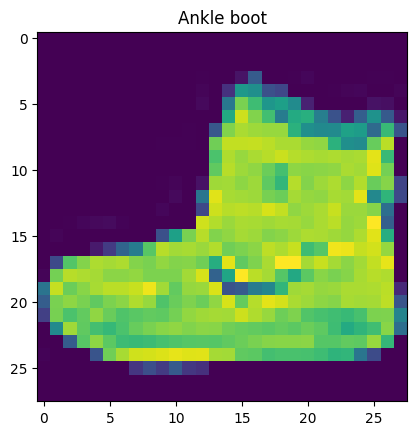

In [ ]:
plt.imshow(train_data[0][0].squeeze())
plt.title(class_names[train_data[0][1]])
plt.show()

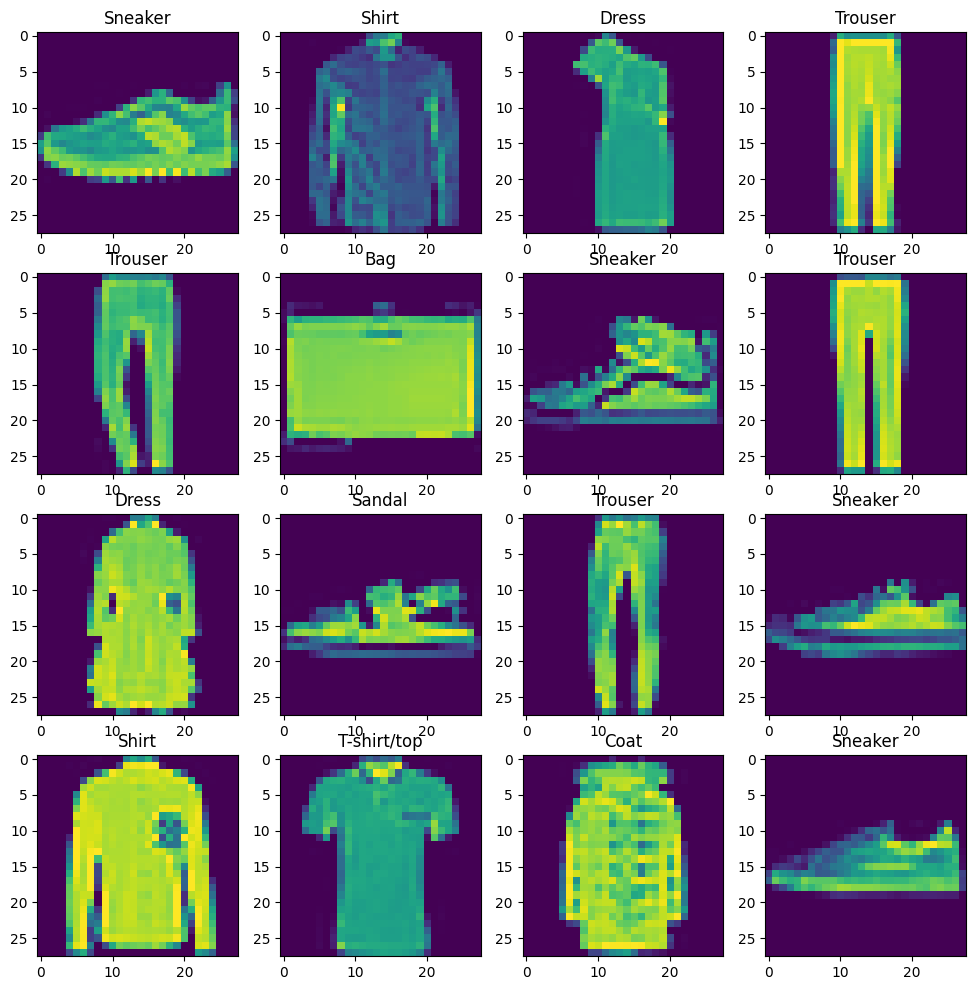

In [ ]:
from numpy import random
torch.manual_seed(42)

rows, cols = 4,4
plt.figure(figsize=(12,12))
for i in range(1,rows*cols+1):
  random_idx = random.randint(0,len(train_data),size=[1]).item()
  image, label = train_data[random_idx]
  plt.subplot(rows,cols,i)
  plt.imshow(image.squeeze())
  plt.title(class_names[label])

In [ ]:
!pip install torch.utils

In [ ]:
import torch.utils
from torch.utils.data import DataLoader
BATCH_SIZE = 32

train_dataloader = DataLoader(dataset = train_data, batch_size = BATCH_SIZE, shuffle = True)
test_dataloader = DataLoader(dataset = test_data, batch_size = BATCH_SIZE, shuffle = True)

In [ ]:
print(f"train_dataloader: {train_dataloader}")
print(f"test_dataloader: {test_dataloader}")

train_dataloader: <torch.utils.data.dataloader.DataLoader object at 0x7be8ba49d1f0>
test_dataloader: <torch.utils.data.dataloader.DataLoader object at 0x7be8ba205430>


In [ ]:
print(f"train_dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"test_dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

train_dataloader: 1875 batches of 32
test_dataloader: 313 batches of 32


In [ ]:
class FashionMNISTV0(nn.Module):
  def __init__(self, input_layers,hidden_layers, output_layers):
    super().__init__()

    self.model = nn.Sequential(nn.Flatten(),
                          nn.Linear(in_features=input_layers, out_features=hidden_layers),
                          nn.ReLU(), # Adding ReLU activation function
                          nn.Linear(in_features=hidden_layers, out_features=output_layers))

    return

  def forward(self,x):
    return self.model(x)

## FashionMNISTV1: Model with Non-Linearity

In [ ]:
class FashionMNISTV1(nn.Module):
  def __init__(self, input_layers,hidden_layers, output_layers):
    super().__init__()

    self.layer_stack = nn.Sequential(nn.Flatten(),
                          nn.Linear(in_features=input_layers, out_features=hidden_layers),
                          nn.ReLU(),
                          nn.Linear(in_features=hidden_layers, out_features=output_layers),
                          nn.ReLU())

    return

  def forward(self,x):
    return self.layer_stack(x)

In [ ]:
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

model_0 = FashionMNISTV0(input_layers=784, hidden_layers=10, output_layers=10).to(device)

model_0

FashionMNISTV0(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

### Instantiate FashionMNISTV1 Model

In [ ]:
torch.manual_seed(42)

model_1 = FashionMNISTV1(input_layers=784, hidden_layers=10, output_layers=10).to(device)

model_1

FashionMNISTV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [ ]:
dummy_x = torch.rand([1,1,28,28])

x_d = model_0(dummy_x)

x_d

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [ ]:
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_pred))*100
  return acc

In [ ]:
from requests.api import request
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [ ]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

### Define Loss Function and Optimizer for FashionMNISTV1

In [ ]:
loss_fn_1 = nn.CrossEntropyLoss()
optimizer_1 = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(42)

epochs = 64

for epoch in tqdm(range(epochs)):
  train_loss = 0
  train_acc = 0

  for batch, (X,y) in enumerate(train_dataloader):
    model_0.train()

    y_pred = model_0(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += accuracy_fn(y_true=y, y_pred=y_pred_class)

    if(batch % 400 == 0):
      print(f"Looked at {batch*len(X)}/{len(train_dataloader.dataset)} samples")

  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)
  print(f"Epoch: {epoch+1} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")

test_loss, test_acc = 0,0
model_0.eval()
with torch.inference_mode():
  for X,y in test_dataloader:
    test_pred = model_0(X)

    test_loss += loss_fn(test_pred, y)

    test_pred_class = torch.argmax(torch.softmax(test_pred, dim=1), dim=1)
    test_acc += accuracy_fn(y_true=y, y_pred=test_pred_class)

  test_loss /= len(test_dataloader)
  test_acc /= len(test_dataloader)

print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

  0%|          | 0/64 [00:00<?, ?it/s]

Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch: 1 | Train Loss: 0.4013 | Train Acc: 85.76%
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch: 2 | Train Loss: 0.3982 | Train Acc: 85.95%
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch: 3 | Train Loss: 0.3977 | Train Acc: 85.98%
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch: 4 | Train Loss: 0.3995 | Train Acc: 85.88%
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch: 5 | Train Loss: 0.3977 | Train Acc: 85.92%
Looked at 0/60000 sa

### Training and Evaluation Loop for FashionMNISTV1

In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(42)

epochs = 64

for epoch in tqdm(range(epochs)):
  train_loss_1 = 0
  train_acc_1 = 0

  for batch, (X,y) in enumerate(train_dataloader):
    model_1.train()

    y_pred_1 = model_1(X)
    loss_1 = loss_fn_1(y_pred_1, y)
    train_loss_1 += loss_1
    optimizer_1.zero_grad()

    loss_1.backward()

    optimizer_1.step()

    y_pred_class_1 = torch.argmax(torch.softmax(y_pred_1, dim=1), dim=1)
    train_acc_1 += accuracy_fn(y_true=y, y_pred=y_pred_class_1)

    if(batch % 400 == 0):
      print(f"Looked at {batch*len(X)}/{len(train_dataloader.dataset)} samples")

  train_loss_1 /= len(train_dataloader)
  train_acc_1 /= len(train_dataloader)
  print(f"Epoch: {epoch+1} | Train Loss (V1): {train_loss_1:.4f} | Train Acc (V1): {train_acc_1:.2f}%")

test_loss_1, test_acc_1 = 0,0
model_1.eval()
with torch.inference_mode():
  for X,y in test_dataloader:
    test_pred_1 = model_1(X)

    test_loss_1 += loss_fn_1(test_pred_1, y)

    test_pred_class_1 = torch.argmax(torch.softmax(test_pred_1, dim=1), dim=1)
    test_acc_1 += accuracy_fn(y_true=y, y_pred=test_pred_class_1)

  test_loss_1 /= len(test_dataloader)
  test_acc_1 /= len(test_dataloader)

print(f"Test Loss (V1): {test_loss_1:.4f} | Test Acc (V1): {test_acc_1:.2f}%")

  0%|          | 0/64 [00:00<?, ?it/s]

Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch: 1 | Train Loss (V1): 1.0920 | Train Acc (V1): 61.34%
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch: 2 | Train Loss (V1): 0.7687 | Train Acc (V1): 72.45%
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch: 3 | Train Loss (V1): 0.6665 | Train Acc (V1): 76.09%
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch: 4 | Train Loss (V1): 0.6413 | Train Acc (V1): 76.72%
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Epoch: 5 | Train Loss (V1): 0.